# Analisis de datasets oficiales ATENEA\n
\n
Este notebook documenta el procesamiento de archivos XLSX reales de eficiencia educativa para explicar riesgo academico dentro del enfoque ODS 4.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

clean = pd.read_csv('DATASETS/processed/official_education_clean.csv')
clean.head()

,periodo,nivel_reporte,nivel,subnivel,control,sostenimiento,poblacion,marginacion,municipio,localidad,...,desercion_pct,egresion_pct,eficiencia_terminal_pct,municipio_normalizado,reprobacion_pct_calc,desercion_pct_calc,eficiencia_terminal_pct_calc,riesgo_score,riesgo_nivel,archivo_origen
0,2020-2021,Media superior,BACHILLERATO GENERAL,Bachillerato General sin Formación para el Tra...,PÚBLICO,FEDERAL,URBANO,MUY BAJO,QUERÉTARO,SANTIAGO DE QUERÉTARO,...,6.293706,95.833336,88.46154,QUERETARO,2.919708,6.293706,88.46154,33.381399,Medio,DATASETS/2020-2021/Pub_Indicadores Fin Ciclo 2...
1,2020-2021,Media superior,BACHILLERATO GENERAL,Bachillerato General sin Formación para el Tra...,PÚBLICO,FEDERAL,URBANO,MUY BAJO,SAN JUAN DEL RÍO,SAN JUAN DEL RÍO,...,-816.666687,0.000000,0.00000,SAN JUAN DEL RIO,100.000000,0.000000,0.00000,100.000000,Alto,DATASETS/2020-2021/Pub_Indicadores Fin Ciclo 2...
2,2020-2021,Media superior,BACHILLERATO GENERAL,Bachillerato General sin Formación para el Tra...,PÚBLICO,FEDERAL,URBANO,BAJO,QUERÉTARO,SANTA MARÍA MAGDALENA,...,5.333333,200.000000,50.00000,QUERETARO,0.000000,5.333333,50.00000,51.000000,Alto,DATASETS/2020-2021/Pub_Indicadores Fin Ciclo 2...
3,2020-2021,Media superior,BACHILLERATO GENERAL,Bachillerato General sin Formación para el Tra...,PÚBLICO,FEDERAL,URBANO,BAJO,TEQUISQUIAPAN,TEQUISQUIAPAN,...,20.000000,0.000000,0.00000,TEQUISQUIAPAN,0.000000,20.000000,0.00000,100.000000,Alto,DATASETS/2020-2021/Pub_Indicadores Fin Ciclo 2...
4,2020-2021,Media superior,BACHILLERATO GENERAL,Bachillerato General sin Formación para el Tra...,PÚBLICO,ESTATAL,URBANO,MUY BAJO,QUERÉTARO,SANTIAGO DE QUERÉTARO,...,-13.333333,183.333328,100.00000,QUERETARO,0.000000,0.000000,100.00000,0.000000,Bajo,DATASETS/2020-2021/Pub_Indicadores Fin Ciclo 2...


## Ciclo de vida de datos\n
\n
1. Ingesta de XLSX oficiales.\n
2. Limpieza de encabezados combinados.\n
3. Normalizacion de columnas clave.\n
4. Calculo de indicadores ponderados.\n
5. Visualizacion para toma de decisiones educativas.

In [5]:
summary = clean.groupby(['periodo', 'nivel_reporte']).agg(
    escuelas=('escuela', 'count'),
    matricula=('existencia', 'sum'),
    riesgo=('riesgo_score', 'mean'),
    reprobacion=('reprobacion_pct_calc', 'mean'),
    desercion=('desercion_pct_calc', 'mean')
).reset_index()
summary

,periodo,nivel_reporte,escuelas,matricula,riesgo,reprobacion,desercion
0,2020-2021,Media superior,308,79283,70.296035,10.474130,15.304703
1,2020-2021,Secundaria,565,119747,26.971666,0.638900,4.886491
2,2021-2022,Media superior,316,78590,50.702264,10.684637,13.380512
3,2021-2022,Secundaria,585,116692,31.844060,0.386933,6.861760
4,2022-2023,Media superior,321,85036,51.789499,10.416618,12.187697
5,2022-2023,Secundaria,585,117799,30.578814,3.128521,4.988610
6,2023-2024,Media superior,319,89320,59.578575,9.375801,11.683610
7,2023-2024,Secundaria,608,119800,28.795650,2.333780,5.432084
8,2024-2025,Media superior,328,92739,56.975969,7.078478,10.523558
9,2024-2025,Secundaria,626,121548,31.948446,2.587355,4.895217


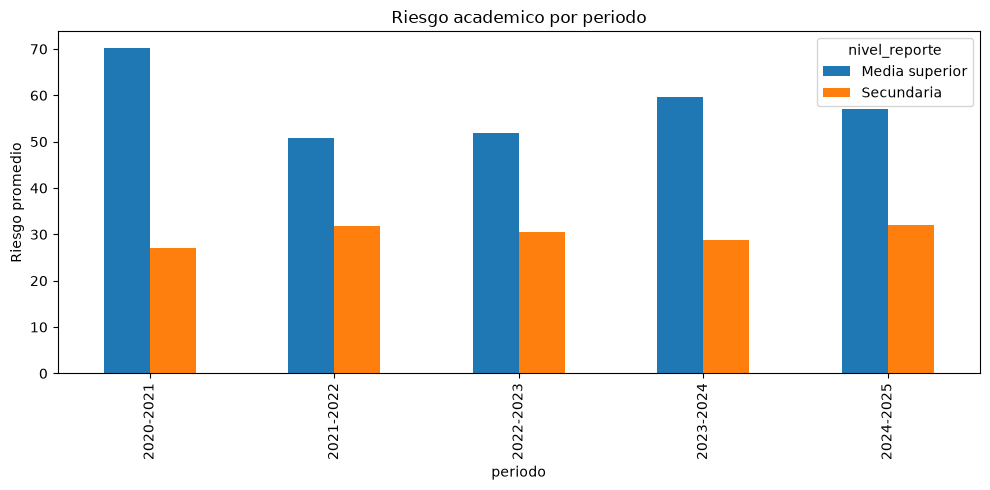

In [6]:
pivot = summary.pivot(index='periodo', columns='nivel_reporte', values='riesgo')
pivot.plot(kind='bar', figsize=(10, 5), title='Riesgo academico por periodo')
plt.ylabel('Riesgo promedio')
plt.tight_layout()
plt.show()

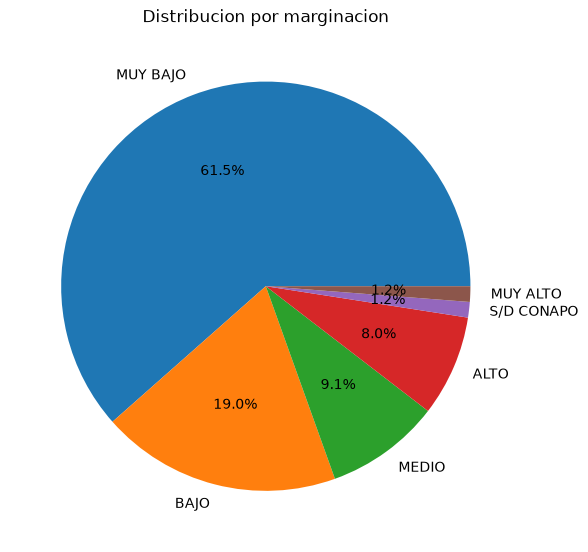

In [7]:
clean['marginacion'].value_counts().head(6).plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title='Distribucion por marginacion')
plt.ylabel('')
plt.tight_layout()
plt.show()